# 🌌 Level 5: High-Dimensional Regression (Visualizing 10+ Features)

**[📖 Want a detailed explanation? Read the Manual (Streamlit App)](https://bookseal-seoul-apt-price-prediction.streamlit.app/Level_5_High_Dimensional)**

In Level 4, we used 3 features (Area, District, Year). What if we want to use **ALL** the available information?

Real-world data often has dozens or hundreds of features. 
In this level, we will:
1.  **Extract** multiple features from the raw data
2.  **Analyze** relationships using a **Correlation Heatmap**
3.  **Train** a model with many features

### 1. Load Data
We'll start with the same dataset.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Load data
url = "https://github.com/bookseal/seoul-apt-price-prediction/raw/main/data/sample.parquet"
df = pd.read_parquet(url)

print(f"Data Loaded! Rows: {len(df):,}")
df.head()

Data Loaded! Rows: 99,995


,sigungu,apartment_name,area_m2,built_year,contract_yyyymm,floor,price_10k_krw,district,year
0,서울특별시 노원구 상계동,북부현대,59.24,1996,201504,4,20000,노원구,2015
1,서울특별시 노원구 월계동,현대,84.98,2000,201503,20,35200,노원구,2015
2,서울특별시 노원구 상계동,은빛1단지,39.70,1998,201501,12,15600,노원구,2015
3,서울특별시 노원구 하계동,벽산,57.71,1988,201507,13,27700,노원구,2015
4,서울특별시 노원구 상계동,상계주공9,41.30,1988,201509,14,18500,노원구,2015


### 2. Prepare Features (Feature Engineering)
We have columns like `built_year`, `floor`, etc. Let's make them usable features or create new ones!

*   `area_m2`: Raw area
*   `year`: From `contract_yyyymm`
*   `floor`: Which floor?
*   `building_age`: How old is the building? (2024 - built_year)
*   `price_per_m2` (Target Analysis): Just to check logic

In [26]:
# 1. Create a copy to avoid warnings
df_feat = df.copy()

# 2. Create Calculated Features
df_feat['building_age'] = 2024 - df_feat['built_year']
df_feat['transaction_year'] = df_feat['contract_yyyymm'] // 100

# 3. Select Numeric Features to Analyze
numeric_features = ['area_m2', 'year', 'floor', 'built_year', 'building_age']
target = 'price_10k_krw'

# Combine for correlation analysis
analysis_cols = numeric_features + [target]
df_analysis = df_feat[analysis_cols]

df_analysis.head()

,area_m2,year,floor,built_year,building_age,price_10k_krw
0,59.24,2015,4,1996,28,20000
1,84.98,2015,20,2000,24,35200
2,39.70,2015,12,1998,26,15600
3,57.71,2015,13,1988,36,27700
4,41.30,2015,14,1988,36,18500


### 3. Feature Selection with Heatmap
Before dumping everything into the model, let's check which features are actually related to Price.

We us a **Correlation Matrix** visualized as a **Heatmap**.

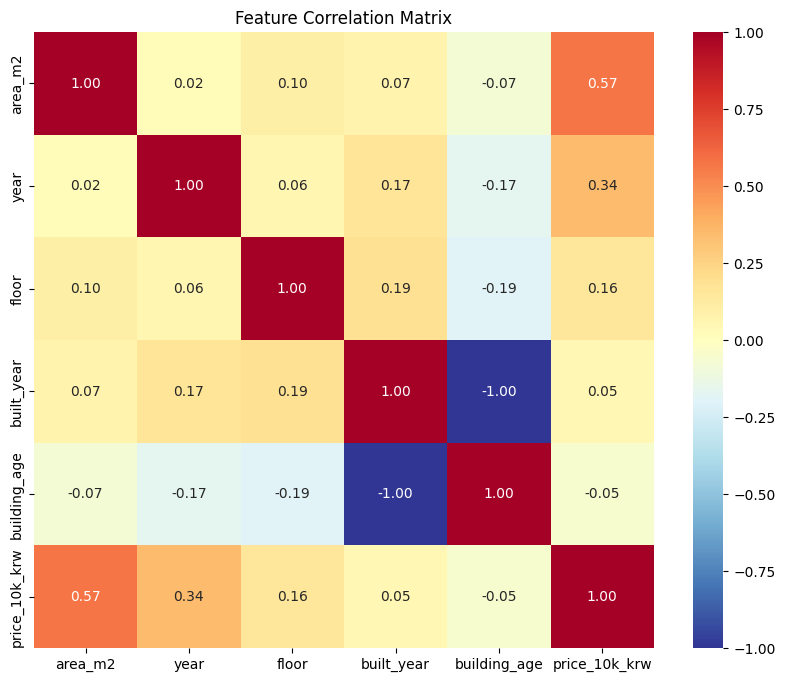

In [27]:
plt.figure(figsize=(10, 8))

# Calculate correlation (-1 to 1)
corr_matrix = df_analysis.corr()

# Draw Heatmap
# annot=True: Show the numbers
# cmap='RdYlBu_r': Red=Positive, Blue=Negative
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

**Analysis:**
1.  Check the `price_10k_krw` row/column.
2.  **High Correlation (Red)**: `area_m2` (0.57). This is our best predictor.
3.  **Low Correlation**: `year` seems weak. `floor` is also weak.
4.  **Redundant Features**: `built_year` and `building_age` have -1.0 correlation (exact opposites). We only need one!

### 4-1. Bonus: Adding District (One-Hot Encoding)
The Heatmap showed numeric features. But `Location` (`district`) is a critical Feature!

**Wait, why "One-Hot Encoding" (Dummy Variables)?**
The `district` column in our data (from Parquet) contains **Text** (e.g., 'Gangnam-gu', 'Nowon-gu').
*   **How Models See Data**: Math models (Lineary Regression) allow only **Numbers**.
*   **Why not 1, 2, 3?**: If we encode Gangnam=1, Nowon=2, the model might think "Nowon is twice Gangnam". This is mathematically wrong for nominal data.

**Solution**: We create a separate "Switch" (0 or 1) for each district.
*   `dist_Gangnam`: 1 if it is Gangnam, 0 if not.
*   This creates 25 new columns (Dummies) representing the location mathematically. This is `pd.get_dummies`.

In [20]:
# 1. One-Hot Encode District
ct = pd.get_dummies(df['district'], prefix='dist')

# Check encoded columns
print(f"District columns created: {ct.shape[1]}")
ct.tail(10)


District columns created: 25


,dist_강남구,dist_강동구,dist_강북구,dist_강서구,dist_관악구,dist_광진구,dist_구로구,dist_금천구,dist_노원구,dist_도봉구,...,dist_성동구,dist_성북구,dist_송파구,dist_양천구,dist_영등포구,dist_용산구,dist_은평구,dist_종로구,dist_중구,dist_중랑구
99985,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
99986,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
99987,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
99988,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
99989,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
99990,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
99991,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
99992,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
99993,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
99994,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### 4. Create the High-D Dataset
We combine Numeric Features + District Features.

In [21]:
# Numeric features
numeric_cols = ['area_m2', 'floor', 'building_age']
X_num = df_feat[numeric_cols].values

# Combine (hstack: Horizontal Stack)
X = np.hstack([X_num, ct.values])

# Target
y = df_feat[target].values

print(f"Final Feature Matrix X shape: {X.shape} (3 numeric + 25 districts)")

Final Feature Matrix X shape: (99995, 28) (3 numeric + 25 districts)


### 5. Train & Evaluate
Split, Train, and Check Performance.

In [22]:
# 1. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Predict
y_pred = model.predict(X_test)

# 4. Score (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE with Numeric + District: {rmse:,.0f} (10k KRW)")

RMSE with Numeric + District: 32,666 (10k KRW)


### 6. Compare with Level 2 (Area Only)
Did adding `floor`, `age`, and `District` help?

In [23]:
# Level 2 Model (Area only) for comparison
X_simple = df[['area_m2']].values
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model_s = LinearRegression()
model_s.fit(X_train_s, y_train_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, model_s.predict(X_test_s)))

print(f"RMSE (Area Only):       {rmse_s:,.0f}")
print(f"RMSE (High-D w/ Dist):  {rmse:,.0f}")
print(f"Improvement:            {rmse_s - rmse:,.0f} points lower error!")

RMSE (Area Only):       38,311
RMSE (High-D w/ Dist):  32,666
Improvement:            5,645 points lower error!
